# Clustering Session 4 — Dimensionality Reduction & Spatial Mapping
### FDP: Machine Learning for Materials and Metallurgical Engineering

Session 3 clustered 2,621 real nanoindentation measurements using up to 13 engineered features. Today:

- **Part A** — Principal Component Analysis (PCA): reducing those 13 features to fewer dimensions, and checking whether clustering quality survives
- **Part B** — Applying our fitted clustering to a real spatial indentation map — turning cluster predictions into an actual microstructure picture

## Setup — Import Libraries and Reload Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score

TRAIN_URL = "https://raw.githubusercontent.com/vijindal/fdp-ml/main/day3/Training_set.csv"
VAL_URL = "https://raw.githubusercontent.com/vijindal/fdp-ml/main/day3/Validation_set.csv"

train = pd.read_csv(TRAIN_URL)
val = pd.read_csv(VAL_URL)
train = train[train.mN == 3].copy()
val = val[val.mN == 3].copy()

label_map = {'matrix': 0, 'mc-matrix': 1, 'm6c-matrix': 2, 'mc': 3, 'm6c': 4}
inv_label_map = {v: k for k, v in label_map.items()}
train['Y'] = train['Y_name'].map(label_map)
val['Y'] = val['Y_name'].map(label_map)

engineered_features = ['slope_0.2', 'norm_slope_0.2', 'curvature', 'curvature_linear', 'curvature_shift',
                        'norm_curvature', 'norm_curvature_linear', 'norm_curvature_shift',
                        'work_total', 'work_elastic', 'work_plastic', 'work_ratio', 'h_ratio']

print("Training rows:", len(train), "| Validation rows:", len(val))


Training rows: 1642 | Validation rows: 412


---
## Part A: Principal Component Analysis (PCA)

### Recap: The Curse of Dimensionality

From Session 1: as the number of features grows, distance-based similarity measures start to break down – in high dimensions, most points end up looking roughly equally “far apart,” making it harder for k-means to find genuine structure.

Our engineered feature set has **13 dimensions**. PCA lets us compress this down to fewer dimensions, keeping most of the meaningful variation, while (hopefully) keeping clustering quality intact.

## Step 1 — How Many Components Do We Actually Need?

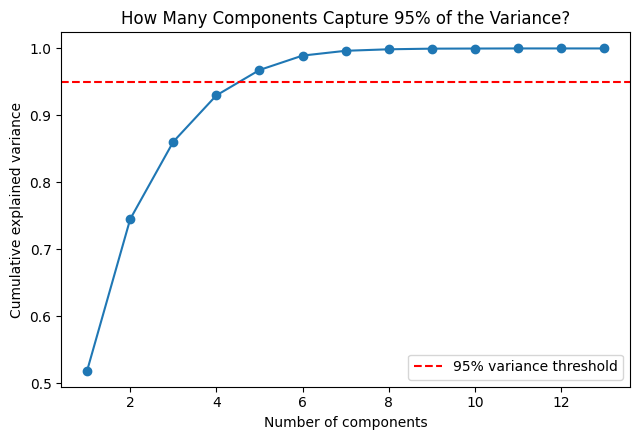

Components needed for 95% variance: 5 (out of 13 original features)
Cumulative variance by component: [0.519 0.745 0.861 0.93  0.968 0.989 0.996 0.999 1.    1.    1.    1.
 1.   ]


In [2]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train[engineered_features])
X_val_scaled = scaler.transform(val[engineered_features])

pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6.5, 4.5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("How Many Components Capture 95% of the Variance?")
plt.legend()
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95} (out of 13 original features)")
print("Cumulative variance by component:", np.round(cumulative_variance, 3))


---
## Quick Check 1

We need only 5 out of 13 original features' worth of information (as principal components) to retain 95% of the variance. What does this tell us about the original 13 engineered features?

**(i)  Most of them are completely useless and should be deleted**
**(ii)  Many of them are correlated with each other – they carry overlapping information, which PCA compresses into fewer independent components**
**(iii)  PCA has made a mistake; all 13 features must be equally important**

*Think about it, then check the answer below.*

**Answer: (ii)** — PCA doesn't discard “useless” features; it finds new axes (combinations of the originals) that capture the shared, correlated variation efficiently. Features like `curvature`, `curvature_linear`, and `curvature_shift` likely overlap heavily in what they measure – exactly the kind of redundancy PCA compresses away.

## Step 2 — Re-Clustering in the Reduced Space

In [3]:
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

km_pca = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_train_pca)
train_pred = km_pca.predict(X_train_pca)
val_pred = km_pca.predict(X_val_pca)

mapping = {}
for cluster_id in np.unique(train_pred):
    mapping[cluster_id] = train['Y'][train_pred == cluster_id].mode()[0]
val_pred_mapped = pd.Series(val_pred).map(mapping)

f1w_pca = f1_score(val['Y'], val_pred_mapped, average='weighted')
f1m_pca = f1_score(val['Y'], val_pred_mapped, average='macro')

print(f"PCA-reduced clustering ({n_components_95} dimensions instead of 13):")
print(f"  F1 weighted = {f1w_pca:.3f}")
print(f"  F1 macro    = {f1m_pca:.3f}")
print()
print("Compare to Session 3's Feature Set B (full 13 dimensions): F1 weighted = 0.763, macro = 0.463")


PCA-reduced clustering (5 dimensions instead of 13):
  F1 weighted = 0.763
  F1 macro    = 0.463

Compare to Session 3's Feature Set B (full 13 dimensions): F1 weighted = 0.763, macro = 0.463


**A clean result:** clustering in just 5 PCA dimensions gives (essentially) the **same F1 scores** as clustering in the full 13-dimensional space. We've compressed the feature set by more than half with no real loss in clustering quality – exactly the payoff PCA promises.

---
## Quick Check 2

Since PCA-reduced clustering performs about the same as using all 13 features, was reducing dimensionality pointless here?

**(i)  Yes – if performance doesn't improve, there's no benefit**
**(ii)  No – matching performance with fewer dimensions is itself valuable: faster computation, less risk from the curse of dimensionality on larger datasets, and it enables the 2D visualization we're about to make**
**(iii)  No – PCA always improves performance, and this is a hidden improvement**

*Think about it, then check the answer below.*

**Answer: (ii)** — “no worse, but simpler” is a genuine win. With a much larger dataset, or many more features, this same dimensionality reduction could matter a great deal for runtime – and as we're about to see, it also makes visualization possible.

## Step 3 — A Visualization Benefit: Seeing 13 Dimensions in 2D

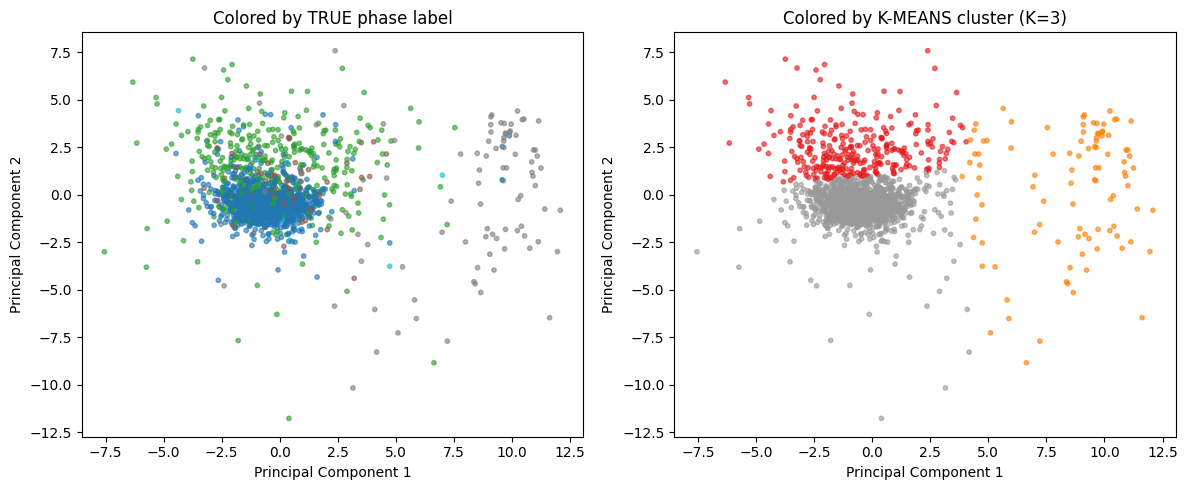

In [4]:
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter1 = axes[0].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=train['Y'], cmap='tab10', s=10, alpha=0.6)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].set_title("Colored by TRUE phase label")

km_2d = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_train_2d)
scatter2 = axes[1].scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=km_2d.labels_, cmap='Set1', s=10, alpha=0.6)
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].set_title("Colored by K-MEANS cluster (K=3)")

plt.tight_layout()
plt.show()


This is something we simply couldn't do with the original 13 dimensions – you can't plot 13 axes on a screen. Reducing to 2 components (even though 2 alone doesn't hit 95% variance) lets us visually compare where k-means' clusters land against the true phase labels, side by side.

---
## Part B: Applying Clustering to a Real Spatial Map

So far we've evaluated clustering against known labels. Now let's see what unsupervised clustering finds when applied **spatially** – across an actual grid of indentation measurements on a real sample.

**Important limitation, stated upfront:** this spatial map only has `Er(GPa)` and `H(GPa)` available (Feature Set A) – the 13 engineered features would require reprocessing raw load-displacement curves we don't have a pipeline for. It also has **no ground-truth phase labels** for this specific map. So what follows is a **predicted-only** visualization – a genuine demonstration of unsupervised clustering, but not a validated accuracy check.

## Step 4 — Fit Feature Set A on the Training Data

In [5]:
feature_set_A = ['Er(GPa)', 'H(GPa)']
scaler_A = StandardScaler()
X_train_A = scaler_A.fit_transform(train[feature_set_A])

km_A = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_train_A)
train_pred_A = km_A.predict(X_train_A)

mapping_A = {}
for cluster_id in np.unique(train_pred_A):
    mapping_A[cluster_id] = train['Y'][train_pred_A == cluster_id].mode()[0]

print("Cluster -> phase label mapping (Feature Set A):")
for cid, label_id in mapping_A.items():
    print(f"  Cluster {cid}  ->  {inv_label_map[label_id]}")


Cluster -> phase label mapping (Feature Set A):
  Cluster 0  ->  mc-matrix
  Cluster 1  ->  mc
  Cluster 2  ->  matrix


## Step 5 — Load the Spatial Map and Predict

In [10]:
MAP_URL = "https://raw.githubusercontent.com/vijindal/fdp-ml/main/day3/HSS_BW_3mN_map01%20LC.txt"
wurfel = pd.read_csv(MAP_URL, sep="\t", skiprows=1, encoding="latin-1")

print("Spatial map shape:", wurfel.shape)

X_wurfel = scaler_A.transform(wurfel[feature_set_A])
wurfel_cluster = km_A.predict(X_wurfel)
wurfel['predicted_label'] = pd.Series(wurfel_cluster).map(mapping_A).map(inv_label_map)

print()
print("Predicted phase distribution across this map:")
print(wurfel['predicted_label'].value_counts())

Spatial map shape: (400, 15)

Predicted phase distribution across this map:
predicted_label
matrix       272
mc-matrix    113
mc            15
Name: count, dtype: int64


## Step 6 — Visualizing the Predicted Microstructure Map

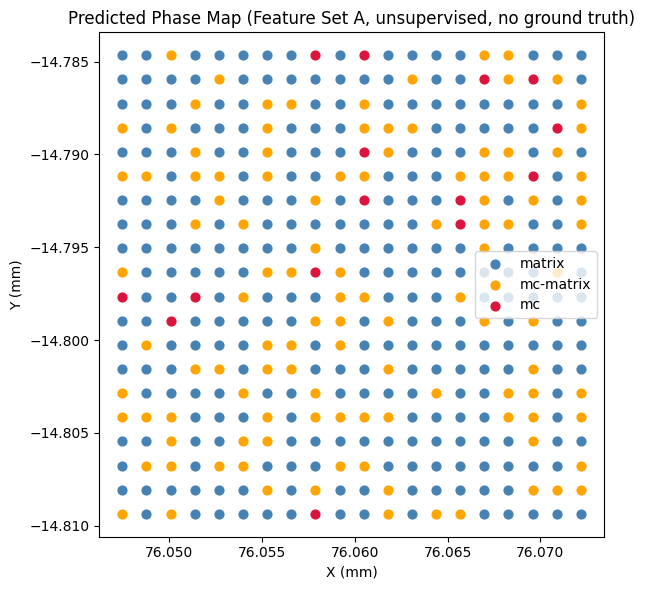

In [11]:
label_colors = {'matrix': 'steelblue', 'mc-matrix': 'orange', 'mc': 'crimson',
                'm6c-matrix': 'green', 'm6c': 'purple'}

plt.figure(figsize=(7, 6))
for label, color in label_colors.items():
    subset = wurfel[wurfel.predicted_label == label]
    if len(subset) > 0:
        plt.scatter(subset['X(mm)'], subset['Y(mm)'], c=color, label=label, s=40)

plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title("Predicted Phase Map (Feature Set A, unsupervised, no ground truth)")
plt.legend()
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()


Notice how the predicted phases aren't randomly scattered – they form spatially coherent regions, which is exactly what we'd expect if the clustering is picking up genuine microstructural features (a matrix phase with embedded carbide regions), rather than noise. Since we have no ground truth for this specific map, we can't quantify accuracy here – but the spatial coherence itself is a reasonable, honest sanity check that the clustering is doing something metallurgically sensible.

---
## Quick Check 3

Since we have no ground-truth labels for this spatial map, what's the most responsible way to interpret the predicted phase map above?

**(i)  Treat it as a fully validated, guaranteed-accurate phase map**
**(ii)  Treat it as a plausible, spatially-coherent hypothesis worth further verification (e.g., against a metallurgist's visual inspection), not a proven result**
**(iii)  Ignore it entirely, since without ground truth it has no value**

*Think about it, then check the answer below.*

**Answer: (ii)** — the spatial coherence is a genuinely encouraging sign, but without ground truth we can't claim validated accuracy. This is the honest, realistic position for most real unsupervised clustering applications – useful, suggestive, but not a substitute for expert verification.

## Wrap-Up: The Clustering Topic, End to End

Across these four sessions:
- **Session 1** – the K-means algorithm itself: assign/update, cost function, manual similarity measures, choosing K (elbow, silhouette), evaluating results, and real limitations (spherical-cluster assumption, curse of dimensionality)
- **Session 2** – the broader landscape: clustering algorithm families (centroid/density/distribution/hierarchical), the clustering workflow, and two real industrial case studies
- **Session 3** – applying K-means to 2,621 real, human-labelled nanoindentation measurements, reproducing a published paper's own finding that feature engineering matters more than adding more features for its own sake
- **Session 4** – PCA for dimensionality reduction (same performance, fewer dimensions, enables visualization), and a real spatial microstructure application

**Next: from unsupervised learning to a new topic.**